In [1]:
#RANEEM - PREPROCESSING AND CLEANING DATA
import os
import zipfile
import random
import numpy as np
import pandas as pd
import joblib
from sklearn.linear_model import Ridge

from sklearn.preprocessing import StandardScaler, LabelEncoder

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 200)

In [2]:
from google.colab import files

print("Please upload the UJIIndoorLoc.zip file.")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Please upload the UJIIndoorLoc.zip file.


Saving ujiindoorloc.zip to ujiindoorloc.zip
User uploaded file "ujiindoorloc.zip" with length 1463759 bytes


In [3]:
import os
import zipfile
import glob

zip_files = glob.glob("/content/*.zip")
print("Found zip files:", zip_files)

if not zip_files:
    raise FileNotFoundError("No zip file found in /content. Upload the zip file first.")

zip_name = zip_files[0] # Changed from zip_name = zip_files to take the first element
extract_dir = "/content/UJIIndoorLoc_extracted"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(extract_dir)

# Adjust extract_dir to point to the actual location of CSVs
extract_dir = os.path.join(extract_dir, "UJIndoorLoc")

print("Using:", zip_name)
print("Extraction complete. Files are ready.")

Found zip files: ['/content/ujiindoorloc.zip']
Using: /content/ujiindoorloc.zip
Extraction complete. Files are ready.


In [4]:
train_path = None
val_path = None

for root, dirs, files_in_dir in os.walk(extract_dir):
    for f in files_in_dir:
        if f == "trainingData.csv":
            train_path = os.path.join(root, f)
        elif f == "validationData.csv":
            val_path = os.path.join(root, f)

if train_path is None or val_path is None:
    raise FileNotFoundError("Could not find trainingData.csv and validationData.csv after extraction.")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

train_df.head()

Train shape: (19937, 529)
Validation shape: (1111, 529)


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,WAP011,WAP012,WAP013,WAP014,WAP015,WAP016,WAP017,WAP018,WAP019,WAP020,WAP021,WAP022,WAP023,WAP024,WAP025,WAP026,WAP027,WAP028,WAP029,WAP030,WAP031,WAP032,WAP033,WAP034,WAP035,WAP036,WAP037,WAP038,WAP039,WAP040,WAP041,WAP042,WAP043,WAP044,WAP045,WAP046,WAP047,WAP048,WAP049,WAP050,WAP051,WAP052,WAP053,WAP054,WAP055,WAP056,WAP057,WAP058,WAP059,WAP060,WAP061,WAP062,WAP063,WAP064,WAP065,WAP066,WAP067,WAP068,WAP069,WAP070,WAP071,WAP072,WAP073,WAP074,WAP075,WAP076,WAP077,WAP078,WAP079,WAP080,WAP081,WAP082,WAP083,WAP084,WAP085,WAP086,WAP087,WAP088,WAP089,WAP090,WAP091,WAP092,WAP093,WAP094,WAP095,WAP096,WAP097,WAP098,WAP099,WAP100,WAP101,WAP102,WAP103,WAP104,WAP105,WAP106,WAP107,WAP108,WAP109,WAP110,WAP111,WAP112,WAP113,WAP114,WAP115,WAP116,WAP117,WAP118,WAP119,WAP120,WAP121,WAP122,WAP123,WAP124,WAP125,WAP126,WAP127,WAP128,WAP129,WAP130,WAP131,WAP132,WAP133,WAP134,WAP135,WAP136,WAP137,WAP138,WAP139,WAP140,WAP141,WAP142,WAP143,WAP144,WAP145,WAP146,WAP147,WAP148,WAP149,WAP150,WAP151,WAP152,WAP153,WAP154,WAP155,WAP156,WAP157,WAP158,WAP159,WAP160,WAP161,WAP162,WAP163,WAP164,WAP165,WAP166,WAP167,WAP168,WAP169,WAP170,WAP171,WAP172,WAP173,WAP174,WAP175,WAP176,WAP177,WAP178,WAP179,WAP180,WAP181,WAP182,WAP183,WAP184,WAP185,WAP186,WAP187,WAP188,WAP189,WAP190,WAP191,WAP192,WAP193,WAP194,WAP195,WAP196,WAP197,WAP198,WAP199,WAP200,WAP201,WAP202,WAP203,WAP204,WAP205,WAP206,WAP207,WAP208,WAP209,WAP210,WAP211,WAP212,WAP213,WAP214,WAP215,WAP216,WAP217,WAP218,WAP219,WAP220,WAP221,WAP222,WAP223,WAP224,WAP225,WAP226,WAP227,WAP228,WAP229,WAP230,WAP231,WAP232,WAP233,WAP234,WAP235,WAP236,WAP237,WAP238,WAP239,WAP240,WAP241,WAP242,WAP243,WAP244,WAP245,WAP246,WAP247,WAP248,WAP249,WAP250,WAP251,WAP252,WAP253,WAP254,WAP255,WAP256,WAP257,WAP258,WAP259,WAP260,WAP261,WAP262,WAP263,WAP264,WAP265,WAP266,WAP267,WAP268,WAP269,WAP270,WAP271,WAP272,WAP273,WAP274,WAP275,WAP276,WAP277,WAP278,WAP279,WAP280,WAP281,WAP282,WAP283,WAP284,WAP285,WAP286,WAP287,WAP288,WAP289,WAP290,WAP291,WAP292,WAP293,WAP294,WAP295,WAP296,WAP297,WAP298,WAP299,WAP300,WAP301,WAP302,WAP303,WAP304,WAP305,WAP306,WAP307,WAP308,WAP309,WAP310,WAP311,WAP312,WAP313,WAP314,WAP315,WAP316,WAP317,WAP318,WAP319,WAP320,WAP321,WAP322,WAP323,WAP324,WAP325,WAP326,WAP327,WAP328,WAP329,WAP330,WAP331,WAP332,WAP333,WAP334,WAP335,WAP336,WAP337,WAP338,WAP339,WAP340,WAP341,WAP342,WAP343,WAP344,WAP345,WAP346,WAP347,WAP348,WAP349,WAP350,WAP351,WAP352,WAP353,WAP354,WAP355,WAP356,WAP357,WAP358,WAP359,WAP360,WAP361,WAP362,WAP363,WAP364,WAP365,WAP366,WAP367,WAP368,WAP369,WAP370,WAP371,WAP372,WAP373,WAP374,WAP375,WAP376,WAP377,WAP378,WAP379,WAP380,WAP381,WAP382,WAP383,WAP384,WAP385,WAP386,WAP387,WAP388,WAP389,WAP390,WAP391,WAP392,WAP393,WAP394,WAP395,WAP396,WAP397,WAP398,WAP399,WAP400,WAP401,WAP402,WAP403,WAP404,WAP405,WAP406,WAP407,WAP408,WAP409,WAP410,WAP411,WAP412,WAP413,WAP414,WAP415,WAP416,WAP417,WAP418,WAP419,WAP420,WAP421,WAP422,WAP423,WAP424,WAP425,WAP426,WAP427,WAP428,WAP429,WAP430,WAP431,WAP432,WAP433,WAP434,WAP435,WAP436,WAP437,WAP438,WAP439,WAP440,WAP441,WAP442,WAP443,WAP444,WAP445,WAP446,WAP447,WAP448,WAP449,WAP450,WAP451,WAP452,WAP453,WAP454,WAP455,WAP456,WAP457,WAP458,WAP459,WAP460,WAP461,WAP462,WAP463,WAP464,WAP465,WAP466,WAP467,WAP468,WAP469,WAP470,WAP471,WAP472,WAP473,WAP474,WAP475,WAP476,WAP477,WAP478,WAP479,WAP480,WAP481,WAP482,WAP483,WAP484,WAP485,WAP486,WAP487,WAP488,WAP489,WAP490,WAP491,WAP492,WAP493,WAP494,WAP495,WAP496,WAP497,WAP498,WAP499,WAP500,WAP501,WAP502,WAP503,WAP504,WAP505,WAP506,WAP507,WAP508,WAP509,WAP510,WAP511,WAP512,WAP513,WAP514,WAP515,WAP516,WAP517,WAP518,WAP519,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100

In [5]:
# 1) Identify feature columns
wap_cols = [c for c in train_df.columns if c.startswith("WAP")]
print("Total WAP columns found:", len(wap_cols))

# 2) Drop exact duplicate rows from training only
train_before = len(train_df)
train_df = train_df.drop_duplicates().reset_index(drop=True)
train_after = len(train_df)
print("Dropped duplicate training rows:", train_before - train_after)

# 3) Remove WAP columns that are never detected in training
# In this dataset, 100 means AP not detected
detected_mask = (train_df[wap_cols] != 100).any(axis=0)
kept_wap_cols = detected_mask[detected_mask].index.tolist()
dropped_wap_cols = [c for c in wap_cols if c not in kept_wap_cols]

print("Kept WAP columns:", len(kept_wap_cols))
print("Dropped never-detected WAP columns:", len(dropped_wap_cols))

# 4) Keep only selected feature columns for X
X_train_raw = train_df[kept_wap_cols].copy()
X_val_raw = val_df[kept_wap_cols].copy()

# 5) Replace 100 with -110
X_train_raw = X_train_raw.replace(100, -110)
X_val_raw = X_val_raw.replace(100, -110)

# 6) Targets
# Classification target = combined building_floor label
y_class_train_str = train_df["BUILDINGID"].astype(str) + "_" + train_df["FLOOR"].astype(str)
y_class_val_str = val_df["BUILDINGID"].astype(str) + "_" + val_df["FLOOR"].astype(str)

# Encoded class labels
label_encoder = LabelEncoder()
y_class_train = label_encoder.fit_transform(y_class_train_str)
y_class_val = label_encoder.transform(y_class_val_str)

# Regression targets
y_reg_train = train_df[["LONGITUDE", "LATITUDE"]].copy()
y_reg_val = val_df[["LONGITUDE", "LATITUDE"]].copy()

# 7) Standardize features using training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)

# 8) Convert back to DataFrames
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=kept_wap_cols)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=kept_wap_cols)

# 9) Build final processed tables
train_processed = X_train_scaled_df.copy()
train_processed["class_label"] = y_class_train_str.values
train_processed["class_label_encoded"] = y_class_train
train_processed["BUILDINGID"] = train_df["BUILDINGID"].values
train_processed["FLOOR"] = train_df["FLOOR"].values
train_processed["LONGITUDE"] = y_reg_train["LONGITUDE"].values
train_processed["LATITUDE"] = y_reg_train["LATITUDE"].values

val_processed = X_val_scaled_df.copy()
val_processed["class_label"] = y_class_val_str.values
val_processed["class_label_encoded"] = y_class_val
val_processed["BUILDINGID"] = val_df["BUILDINGID"].values
val_processed["FLOOR"] = val_df["FLOOR"].values
val_processed["LONGITUDE"] = y_reg_val["LONGITUDE"].values
val_processed["LATITUDE"] = y_reg_val["LATITUDE"].values

print("\nFinal processed shapes")
print("X_train:", X_train_scaled_df.shape)
print("X_val:", X_val_scaled_df.shape)
print("train_processed:", train_processed.shape)
print("val_processed:", val_processed.shape)

print("\nSample class labels:", list(label_encoder.classes_[:10]))
train_processed.head()

Total WAP columns found: 520
Dropped duplicate training rows: 637
Kept WAP columns: 465
Dropped never-detected WAP columns: 55

Final processed shapes
X_train: (19300, 465)
X_val: (1111, 465)
train_processed: (19300, 471)
val_processed: (1111, 471)

Sample class labels: ['0_0', '0_1', '0_2', '0_3', '1_0', '1_1', '1_2', '1_3', '2_0', '2_1']


,WAP001,WAP002,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,WAP011,WAP012,WAP013,WAP014,WAP015,WAP016,WAP017,WAP018,WAP019,WAP020,WAP021,WAP022,WAP023,WAP024,WAP025,WAP026,WAP027,WAP028,WAP029,WAP030,WAP031,WAP032,WAP033,WAP034,WAP035,WAP036,WAP037,WAP038,WAP039,WAP040,WAP041,WAP042,WAP043,WAP044,WAP045,WAP046,WAP047,WAP048,WAP049,WAP050,WAP051,WAP052,WAP053,WAP054,WAP055,WAP056,WAP057,WAP058,WAP059,WAP060,WAP061,WAP062,WAP063,WAP064,WAP065,WAP066,WAP067,WAP068,WAP069,WAP070,WAP071,WAP072,WAP073,WAP074,WAP075,WAP076,WAP077,WAP078,WAP079,WAP080,WAP081,WAP082,WAP083,WAP084,WAP085,WAP086,WAP087,WAP088,WAP089,WAP090,WAP091,WAP096,WAP097,WAP098,WAP099,WAP100,WAP101,WAP102,WAP103,WAP104,WAP105,WAP106,WAP107,WAP108,WAP109,WAP110,WAP111,WAP112,WAP113,WAP114,WAP115,WAP116,WAP117,WAP118,WAP119,WAP120,WAP121,WAP122,WAP123,WAP124,WAP125,WAP126,WAP127,WAP128,WAP129,WAP130,WAP131,WAP132,WAP133,WAP134,WAP135,WAP136,WAP137,WAP138,WAP139,WAP140,WAP141,WAP142,WAP143,WAP144,WAP145,WAP146,WAP147,WAP148,WAP149,WAP150,WAP151,WAP153,WAP154,WAP155,WAP156,WAP157,WAP161,WAP162,WAP163,WAP164,WAP165,WAP166,WAP167,WAP168,WAP169,WAP170,WAP171,WAP172,WAP173,WAP174,WAP175,WAP176,WAP177,WAP178,WAP179,WAP180,WAP181,WAP182,WAP183,WAP184,WAP185,WAP186,WAP187,WAP188,WAP189,WAP190,WAP191,WAP192,WAP193,WAP194,WAP195,WAP196,WAP197,WAP198,WAP199,WAP200,WAP201,WAP202,WAP203,WAP204,WAP205,WAP206,WAP207,WAP208,WAP209,WAP210,WAP211,WAP212,WAP213,WAP214,WAP216,WAP218,WAP219,WAP220,WAP221,WAP222,WAP223,WAP224,WAP225,WAP228,WAP229,WAP230,WAP231,WAP232,WAP233,WAP234,WAP235,WAP236,WAP237,WAP248,WAP249,WAP250,WAP251,WAP252,WAP253,WAP255,WAP256,WAP257,WAP258,WAP259,WAP260,WAP261,WAP262,WAP263,WAP264,WAP265,WAP266,WAP267,WAP268,WAP269,WAP270,WAP271,WAP272,WAP273,WAP274,WAP275,WAP276,WAP277,WAP278,WAP279,WAP280,WAP281,WAP282,WAP283,WAP284,WAP285,WAP286,WAP287,WAP288,WAP289,WAP290,WAP291,WAP292,WAP294,WAP295,WAP297,WAP298,WAP299,WAP300,WAP302,WAP305,WAP306,WAP308,WAP309,WAP310,WAP311,WAP312,WAP313,WAP314,WAP315,WAP316,WAP317,WAP318,WAP319,WAP320,WAP321,WAP322,WAP323,WAP324,WAP325,WAP326,WAP327,WAP328,WAP329,WAP330,WAP331,WAP332,WAP334,WAP335,WAP336,WAP337,WAP338,WAP339,WAP340,WAP341,WAP342,WAP343,WAP344,WAP345,WAP346,WAP347,WAP348,WAP350,WAP351,WAP352,WAP354,WAP355,WAP356,WAP357,WAP358,WAP359,WAP361,WAP362,WAP363,WAP364,WAP366,WAP367,WAP368,WAP369,WAP370,WAP371,WAP372,WAP373,WAP374,WAP375,WAP376,WAP377,WAP378,WAP379,WAP380,WAP381,WAP382,WAP383,WAP384,WAP385,WAP386,WAP387,WAP388,WAP389,WAP390,WAP391,WAP392,WAP393,WAP394,WAP395,WAP396,WAP397,WAP398,WAP399,WAP400,WAP401,WAP402,WAP403,WAP404,WAP405,WAP406,WAP407,WAP408,WAP409,WAP410,WAP411,WAP412,WAP413,WAP414,WAP415,WAP417,WAP418,WAP420,WAP421,WAP422,WAP424,WAP425,WAP426,WAP427,WAP428,WAP430,WAP431,WAP432,WAP434,WAP435,WAP436,WAP437,WAP439,WAP440,WAP443,WAP446,WAP447,WAP448,WAP449,WAP450,WAP452,WAP453,WAP454,WAP455,WAP456,WAP457,WAP459,WAP460,WAP461,WAP462,WAP463,WAP464,WAP465,WAP466,WAP467,WAP468,WAP469,WAP470,WAP471,WAP472,WAP473,WAP474,WAP475,WAP476,WAP477,WAP478,WAP479,WAP480,WAP481,WAP483,WAP484,WAP486,WAP489,WAP490,WAP492,WAP493,WAP494,WAP495,WAP496,WAP498,WAP499,WAP500,WAP501,WAP502,WAP503,WAP504,WAP505,WAP506,WAP507,WAP508,WAP509,WAP510,WAP511,WAP512,WAP513,WAP514,WAP515,WAP516,WAP517,WAP518,WAP519,class_label,class_label_encoded,BUILDINGID,FLOOR,LONGITUDE,LATITUDE
0,-0.030467,-0.031264,-0.04524,-0.120339,-0.162513,-0.170228,-0.169735,-0.055194,-0.37653,-0.378071,-0.320968,-0.318944,-0.213713,-0.216216,-0.064939,-0.06653,-0.14321,-0.138117,-0.043468,-0.043486,-0.1836,-0.184471,-0.174023,-0.177969,-0.188371,-0.193014,-0.273333,-0.277774,-0.167352,-0.16833,-0.279483,-0.279227,-0.299797,-0.299782,-0.170698,-0.165128,-0.273384,-0.276693,-0.296676,-0.299606,-0.240567,-0.244436,-0.182738,-0.186617,-0.263434,-0.264633,-0.137719,-0.142259,-0.340863,-0.337715,-0.222536,-0.224451,-0.039335,-0.040864,-0.154904,-0.159664,-0.321104,-0.337802,-0.460256,-0.466714,-0.404785,-0.401946,-0.435956,-0.444583,-0.290826,-0.294948,-0.468409,-0.478158,-

In [6]:
print("NaNs in X_train?", X_train_scaled_df.isna().sum().sum())
print("NaNs in X_val?", X_val_scaled_df.isna().sum().sum())

print("\nTraining class distribution (top 10):")
print(train_processed["class_label"].value_counts().head(10))

print("\nRegression target summary:")
display(train_processed[["LONGITUDE", "LATITUDE"]].describe())

print("\nExample feature range after scaling:")
display(X_train_scaled_df.iloc[:, :10].describe().T[["mean", "std", "min", "max"]])

NaNs in X_train? 0
NaNs in X_val? 0

Training class distribution (top 10):
class_label
2_3    2708
2_1    2162
2_0    1942
2_2    1577
0_2    1443
1_2    1396
0_3    1390
0_1    1356
1_0    1333
1_1    1266
Name: count, dtype: int64

Regression target summary:


,LONGITUDE,LATITUDE
count,19300.000000,1.930000e+04
mean,-7465.895415,4.864871e+06
std,124.193917,6.757639e+01
min,-7691.338400,4.864746e+06
25%,-7596.648700,4.864821e+06
50%,-7423.182180,4.864853e+06
75%,-7359.297900,4.864930e+06
max,-7300.818990,4.865017e+06



Example feature range after scaling:


,mean,std,min,max
WAP001,1.066035e-14,1.000026,-0.030467,37.833932
WAP002,9.065494e-15,1.000026,-0.031264,34.448487
WAP005,-6.785867e-15,1.000026,-0.045240,26.185990
WAP006,-1.178102e-16,1.000026,-0.120339,16.047297
WAP007,-1.472627e-16,1.000026,-0.162513,11.897276
WAP008,6.405929e-16,1.000026,-0.170228,9.812692
WAP009,5.183649e-16,1.000026,-0.169735,10.087174
WAP010,6.774086e-15,1.000026,-0.055194,25.168952
WAP011,9.424816e-17,1.000026,-0.376530,7.564939
WAP012,2.356204e-16,1.000026,-0.378071,7.754922


In [7]:
SAVE_DIR = "/content/drive/MyDrive/DSAI3201_shared_preprocessing"
os.makedirs(SAVE_DIR, exist_ok=True)

train_csv_path = os.path.join(SAVE_DIR, "train_processed.csv")
val_csv_path = os.path.join(SAVE_DIR, "validation_processed.csv")
artifacts_path = os.path.join(SAVE_DIR, "preprocessing_artifacts.joblib")

train_processed.to_csv(train_csv_path, index=False)
val_processed.to_csv(val_csv_path, index=False)

joblib.dump(
    {
        "kept_wap_cols": kept_wap_cols,
        "dropped_wap_cols": dropped_wap_cols,
        "scaler": scaler,
        "label_encoder": label_encoder
    },
    artifacts_path
)

print("Saved:")
print(train_csv_path)
print(val_csv_path)
print(artifacts_path)

Saved:
/content/drive/MyDrive/DSAI3201_shared_preprocessing/train_processed.csv
/content/drive/MyDrive/DSAI3201_shared_preprocessing/validation_processed.csv
/content/drive/MyDrive/DSAI3201_shared_preprocessing/preprocessing_artifacts.joblib


In [8]:
# EDA-only helper features from the cleaned but unscaled RSSI table
train_rssi_for_eda = X_train_raw.copy()
val_rssi_for_eda = X_val_raw.copy()

# Count how many APs were detected in each sample
train_detected_ap_count = (train_rssi_for_eda > -110).sum(axis=1)
val_detected_ap_count = (val_rssi_for_eda > -110).sum(axis=1)

# Strongest and average detected RSSI per sample
def sample_signal_stats(df):
    strongest = []
    mean_detected = []
    for _, row in df.iterrows():
        detected = row[row > -110]
        if len(detected) == 0:
            strongest.append(-110)
            mean_detected.append(-110)
        else:
            strongest.append(detected.max())
            mean_detected.append(detected.mean())
    return pd.Series(strongest), pd.Series(mean_detected)

train_strongest_rssi, train_mean_detected_rssi = sample_signal_stats(train_rssi_for_eda)
val_strongest_rssi, val_mean_detected_rssi = sample_signal_stats(val_rssi_for_eda)

eda_train_summary = pd.DataFrame({
    "class_label": y_class_train_str.values,
    "BUILDINGID": train_df["BUILDINGID"].values,
    "FLOOR": train_df["FLOOR"].values,
    "LONGITUDE": train_df["LONGITUDE"].values,
    "LATITUDE": train_df["LATITUDE"].values,
    "detected_ap_count": train_detected_ap_count.values,
    "strongest_rssi": train_strongest_rssi.values,
    "mean_detected_rssi": train_mean_detected_rssi.values
})

eda_val_summary = pd.DataFrame({
    "class_label": y_class_val_str.values,
    "BUILDINGID": val_df["BUILDINGID"].values,
    "FLOOR": val_df["FLOOR"].values,
    "LONGITUDE": val_df["LONGITUDE"].values,
    "LATITUDE": val_df["LATITUDE"].values,
    "detected_ap_count": val_detected_ap_count.values,
    "strongest_rssi": val_strongest_rssi.values,
    "mean_detected_rssi": val_mean_detected_rssi.values
})

eda_train_summary.head()

,class_label,BUILDINGID,FLOOR,LONGITUDE,LATITUDE,detected_ap_count,strongest_rssi,mean_detected_rssi
0,1_2,1,2,-7541.2643,4.864921e+06,17,-53,-77.647059
1,1_2,1,2,-7536.6212,4.864934e+06,16,-46,-76.625000
2,1_2,1,2,-7519.1524,4.864950e+06,15,-61,-82.933333
3,1_2,1,2,-7524.5704,4.864934e+06,16,-55,-77.562500
4,0_0,0,0,-7632.1436,4.864982e+06,0,-110,-110.000000


In [9]:
preprocessing_summary = pd.DataFrame({
    "Metric": [
        "Original training rows",
        "Training rows after duplicate removal",
        "Dropped duplicate training rows",
        "Original WAP features",
        "WAP features kept",
        "WAP features removed (never detected in training)",
        "Validation rows",
        "Unique building-floor classes in training"
    ],
    "Value": [
        train_before,
        train_after,
        train_before - train_after,
        len(wap_cols),
        len(kept_wap_cols),
        len(dropped_wap_cols),
        len(val_df),
        y_class_train_str.nunique()
    ]
})

display(preprocessing_summary)

,Metric,Value
0,Original training rows,19937
1,Training rows after duplicate removal,19300
2,Dropped duplicate training rows,637
3,Original WAP features,520
4,WAP features kept,465
5,WAP features removed (never detected in training),55
6,Validation rows,1111
7,Unique building-floor classes in training,13


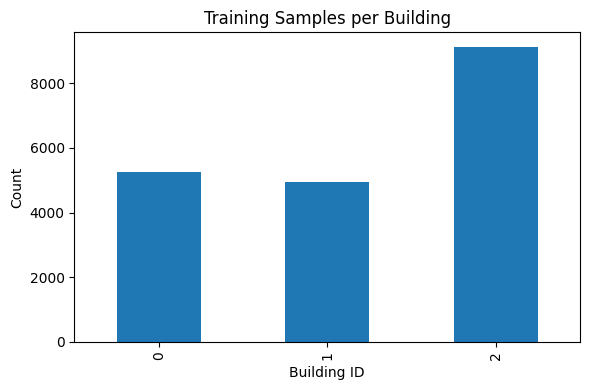

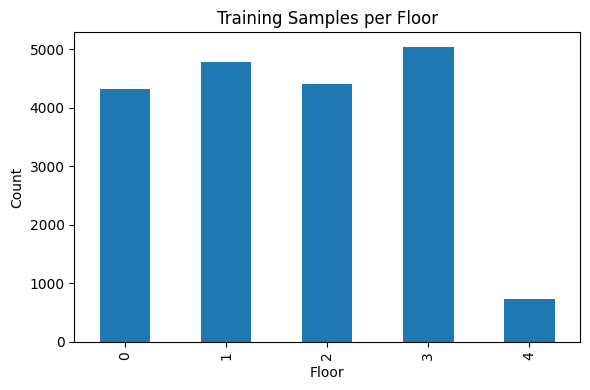

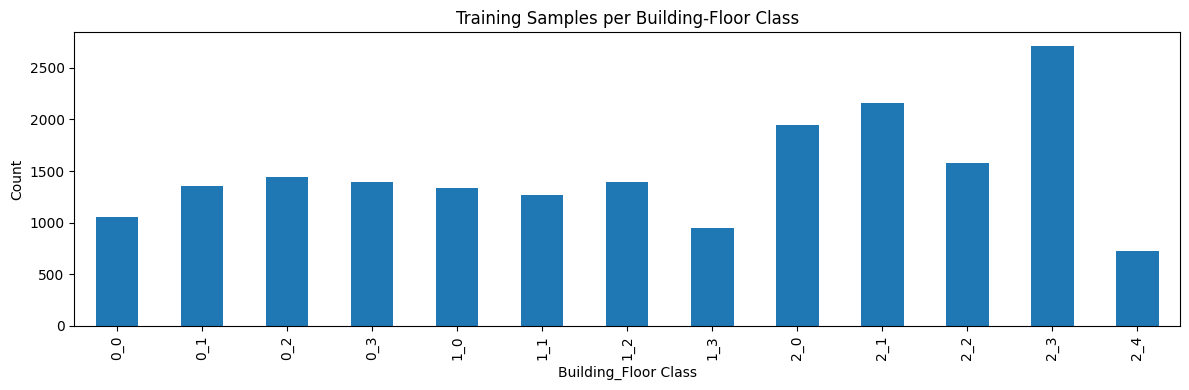

In [10]:
import matplotlib.pyplot as plt

# Building distribution
plt.figure(figsize=(6,4))
train_df["BUILDINGID"].value_counts().sort_index().plot(kind="bar")
plt.title("Training Samples per Building")
plt.xlabel("Building ID")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Floor distribution
plt.figure(figsize=(6,4))
train_df["FLOOR"].value_counts().sort_index().plot(kind="bar")
plt.title("Training Samples per Floor")
plt.xlabel("Floor")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Building-floor class distribution
plt.figure(figsize=(12,4))
y_class_train_str.value_counts().sort_index().plot(kind="bar")
plt.title("Training Samples per Building-Floor Class")
plt.xlabel("Building_Floor Class")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

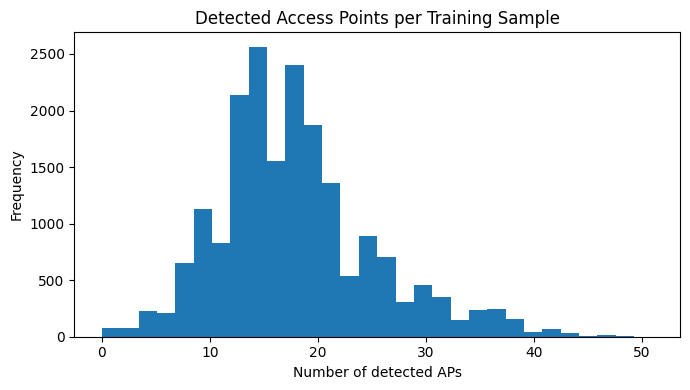

Detected AP count summary:


,detected_ap_count
count,19300.000000
mean,17.879793
std,7.320780
min,0.000000
25%,13.000000
50%,17.000000
75%,21.000000
max,51.000000


In [11]:
plt.figure(figsize=(7,4))
plt.hist(eda_train_summary["detected_ap_count"], bins=30)
plt.title("Detected Access Points per Training Sample")
plt.xlabel("Number of detected APs")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Detected AP count summary:")
display(eda_train_summary["detected_ap_count"].describe())

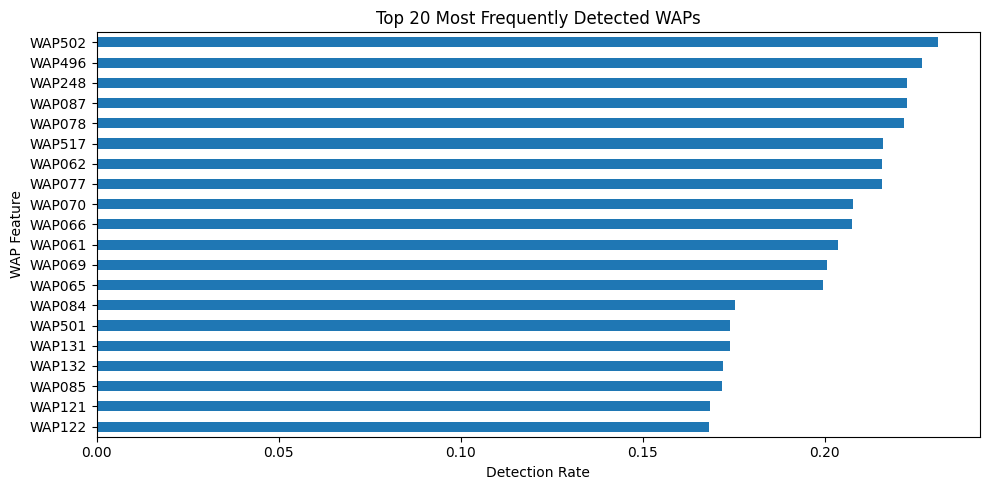

,detection_rate
WAP502,0.231088
WAP496,0.226684
WAP087,0.222642
WAP248,0.222642
WAP078,0.221813
WAP517,0.215959
WAP062,0.215855
WAP077,0.215751
WAP070,0.207668
WAP066,0.207409


In [12]:
# Detection rate per WAP in training
wap_detection_rate = (X_train_raw > -110).mean().sort_values(ascending=False)

top_n = 20
top_detected_waps = wap_detection_rate.head(top_n)

plt.figure(figsize=(10,5))
top_detected_waps.sort_values().plot(kind="barh")
plt.title(f"Top {top_n} Most Frequently Detected WAPs")
plt.xlabel("Detection Rate")
plt.ylabel("WAP Feature")
plt.tight_layout()
plt.show()

display(top_detected_waps.to_frame("detection_rate"))

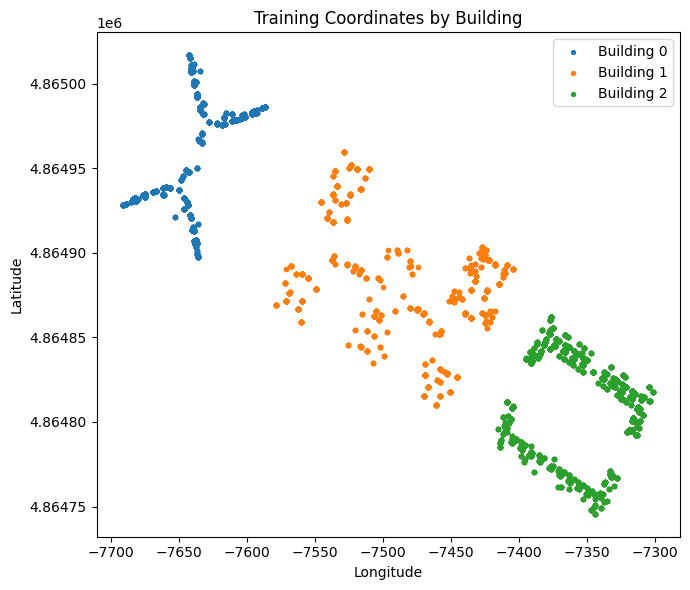

In [13]:
plt.figure(figsize=(7,6))

for b in sorted(train_df["BUILDINGID"].unique()):
    subset = train_df[train_df["BUILDINGID"] == b]
    plt.scatter(subset["LONGITUDE"], subset["LATITUDE"], label=f"Building {b}", s=8)

plt.title("Training Coordinates by Building")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

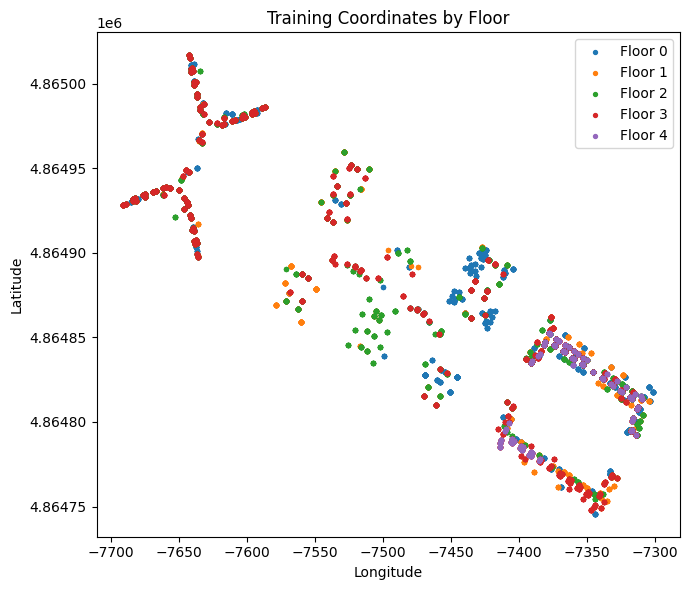

In [14]:
plt.figure(figsize=(7,6))

for f in sorted(train_df["FLOOR"].unique()):
    subset = train_df[train_df["FLOOR"] == f]
    plt.scatter(subset["LONGITUDE"], subset["LATITUDE"], label=f"Floor {f}", s=8)

plt.title("Training Coordinates by Floor")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
scaling_check = X_train_scaled_df.describe().T[["mean", "std"]]
display(scaling_check.head(15))

print("Average absolute mean across scaled features:", scaling_check["mean"].abs().mean())
print("Average std across scaled features:", scaling_check["std"].mean())

,mean,std
WAP001,1.066035e-14,1.000026
WAP002,9.065494e-15,1.000026
WAP005,-6.785867e-15,1.000026
WAP006,-1.178102e-16,1.000026
WAP007,-1.472627e-16,1.000026
WAP008,6.405929e-16,1.000026
WAP009,5.183649e-16,1.000026
WAP010,6.774086e-15,1.000026
WAP011,9.424816e-17,1.000026
WAP012,2.356204e-16,1.000026


Average absolute mean across scaled features: 5.002874041273199e-15
Average std across scaled features: 1.0000259077425584


In [16]:
eda_train_path = os.path.join(SAVE_DIR, "eda_train_summary.csv")
eda_val_path = os.path.join(SAVE_DIR, "eda_validation_summary.csv")
prep_summary_path = os.path.join(SAVE_DIR, "preprocessing_summary.csv")
wap_detection_path = os.path.join(SAVE_DIR, "wap_detection_rates.csv")

eda_train_summary.to_csv(eda_train_path, index=False)
eda_val_summary.to_csv(eda_val_path, index=False)
preprocessing_summary.to_csv(prep_summary_path, index=False)
wap_detection_rate.to_csv(wap_detection_path, header=["detection_rate"])

print("Saved:")
print(eda_train_path)
print(eda_val_path)
print(prep_summary_path)
print(wap_detection_path)

Saved:
/content/drive/MyDrive/DSAI3201_shared_preprocessing/eda_train_summary.csv
/content/drive/MyDrive/DSAI3201_shared_preprocessing/eda_validation_summary.csv
/content/drive/MyDrive/DSAI3201_shared_preprocessing/preprocessing_summary.csv
/content/drive/MyDrive/DSAI3201_shared_preprocessing/wap_detection_rates.csv


In [17]:
# NUR AFIQAH MODELING (SIMPLE REGRESSOR AND ADVANCED CLASSIFICATION)

# Simple Regressor model: KNN

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Define regression targets from previously processed data
y_train_reg = y_reg_train.values
y_val_reg = y_reg_val.values

# Initialize the model (k=5 is a standard starting point)
knn_regressor = KNeighborsRegressor(n_neighbors=7)

# Train
knn_regressor.fit(X_train_scaled, y_train_reg)

# Predict
y_pred_knn = knn_regressor.predict(X_val_scaled)

# Evaluate
mae_knn = mean_absolute_error(y_val_reg, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_val_reg, y_pred_knn))

print(f"Baseline k-NN Regression Results:")
print(f"Mean Absolute Error (MAE): {mae_knn:.2f} meters")
print(f"Root Mean Squared Error (RMSE): {rmse_knn:.2f} meters")

Baseline k-NN Regression Results:
Mean Absolute Error (MAE): 8.14 meters
Root Mean Squared Error (RMSE): 15.66 meters


The preprocessing pipeline was standardized across all team members to ensure fair comparison between models.
The original training dataset contained {train_before} samples, and {train_before - train_after} exact duplicate
rows were removed, leaving {train_after} training samples. A total of {len(wap_cols)} WiFi access-point (WAP)
features were examined. Since the value 100 in the UJIndoorLoc dataset represents an undetected access point rather
than a valid RSSI measurement, all such values were replaced with -110 dBm to preserve the meaning of signal absence.
WAP features that were never detected in the training set were removed, reducing the feature space from {len(wap_cols)}
to {len(kept_wap_cols)} useful predictors. The remaining RSSI features were standardized using StandardScaler fitted
only on the training data, and the same transformation was applied to the validation set. For classification, a
combined building-floor label was created, while longitude and latitude were retained as the regression targets.


In [18]:
# Initialize the encoder
le = LabelEncoder()

# Create combined labels: "BuildingID_FloorID"
train_labels = train_df['BUILDINGID'].astype(str) + "_" + train_df['FLOOR'].astype(str)
val_labels = val_df['BUILDINGID'].astype(str) + "_" + val_df['FLOOR'].astype(str)

# Transform into the variables the CNN will use
y_train_class = le.fit_transform(train_labels)
y_val_class = le.transform(val_labels)

# Save the number of classes for the CNN output layer
num_classes = len(le.classes_)
print(f"Ready to classify {num_classes} unique Building-Floor locations.")

# Assuming X_train_scaled and X_val_scaled are already defined from your StandardScaler step
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_val_cnn = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)

print(f"CNN Input Shape: {X_train_cnn.shape}")
# Should show (19300, 465, 1)

Ready to classify 13 unique Building-Floor locations.
CNN Input Shape: (19300, 465, 1)


In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Define the CNN Architecture
cnn_model = models.Sequential([
    # First Convolutional Block
    layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(465, 1)),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2), # Prevents overfitting to noisy signals

    # Second Convolutional Block
    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(), # Flattens the 2D patterns into a 1D vector

    # Fully Connected Layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # Output Layer: 13 units for our 13 Building-Floor combos
    layers.Dense(num_classes, activation='softmax')
])

# 2. Compile the Model
# We use 'sparse_categorical_crossentropy' because our labels (0-12) are integers
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# 3. View the Model Summary
cnn_model.summary()

# 4. Train the Model
# 20 epochs is usually enough to see if it's learning well
history = cnn_model.fit(X_train_cnn, y_train_class,
                        epochs=20,
                        batch_size=32,
                        validation_data=(X_val_cnn, y_val_class))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 463, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 231, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 231, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 229, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 114, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14592)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,867,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,894,541 (7.23 MB)

 Trainable params: 1,894,541 (7.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.9387 - loss: 0.2271 - val_accuracy: 0.8848 - val_loss: 0.5841
Epoch 2/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - accuracy: 0.9789 - loss: 0.0703 - val_accuracy: 0.9028 - val_loss: 0.5736
Epoch 3/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - accuracy: 0.9876 - loss: 0.0411 - val_accuracy: 0.9127 - val_loss: 0.6036
Epoch 4/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9884 - loss: 0.0392 - val_accuracy: 0.9019 - val_loss: 0.8800
Epoch 5/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9911 - loss: 0.0269 - val_accuracy: 0.9100 - val_loss: 0.8210
Epoch 6/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 39s 64ms/step - accuracy: 0.9908 - loss: 0.0265 - val_accuracy: 0.9010 - val_loss: 1.0418
Epoch 7/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - accuracy: 0.9915 - loss: 0.0287 - val_accuracy: 0.9019 - val_loss: 0.9189
Epoch 8/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.9916 - loss: 0.0261 - 

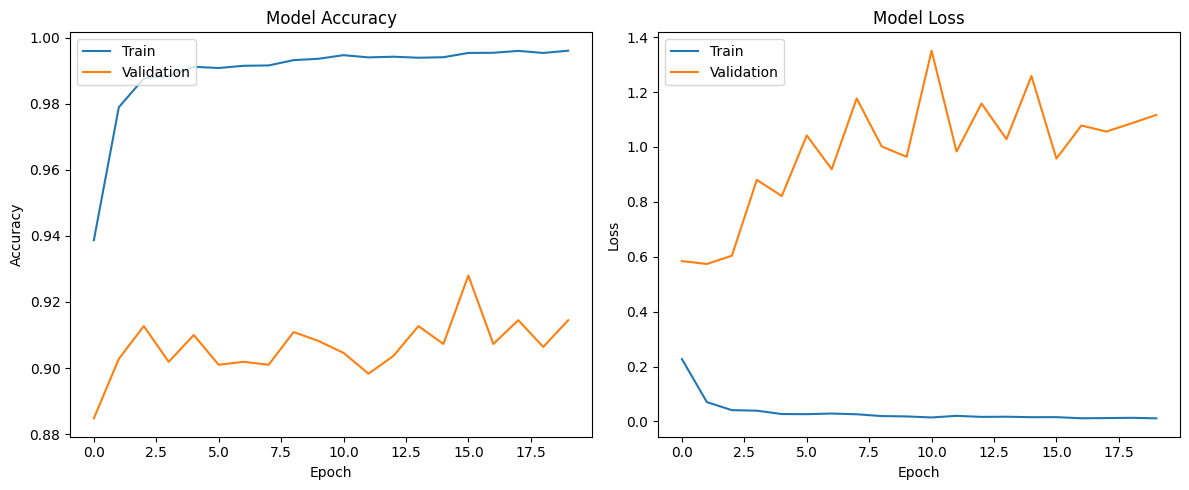

In [20]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

           0       0.88      0.95      0.91        78
           1       0.96      0.91      0.94       208
           2       0.88      0.96      0.92       165
           3       0.97      0.86      0.91        85
           4       0.93      0.83      0.88        30
           5       0.98      0.83      0.89       143
           6       0.74      0.92      0.82        87
           7       0.88      0.96      0.92        47
           8       0.96      0.92      0.94        24
           9       0.98      0.98      0.98       111
          10       0.96      0.94      0.95        54
          11       0.86      0.93      0.89        40
          12       0.89      0.87      0.88        39

    accuracy                           0.91      1111
   macro avg       0.91      0.91      0.91      1111
weighted avg       0.92      0.91      0.92      1111



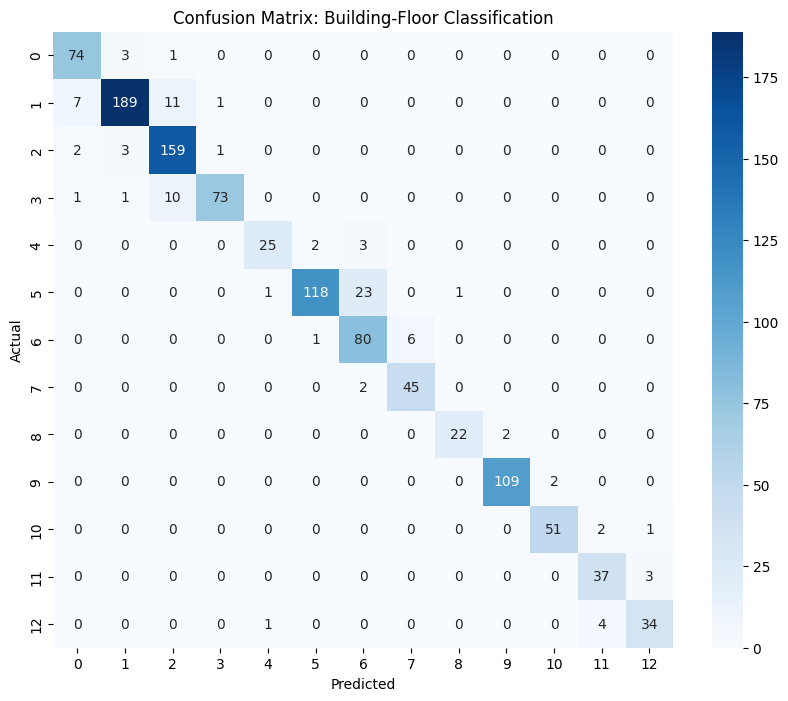

In [21]:
# Get the class predictions
y_pred_classes = np.argmax(cnn_model.predict(X_val_cnn), axis=1)

# Print a detailed report
print(classification_report(y_val_class, y_pred_classes))

# Plot the Confusion Matrix
plt.figure(figsize=(10,8))
cm = confusion_matrix(y_val_class, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Building-Floor Classification')
plt.show()

In [22]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error
)

accuracy = accuracy_score(y_val_class, y_pred_classes)
precision = precision_score(y_val_class, y_pred_classes, average="macro", zero_division=0)
recall = recall_score(y_val_class, y_pred_classes, average="macro", zero_division=0)
f1 = f1_score(y_val_class, y_pred_classes, average="macro", zero_division=0)

print("Simple Classification (Linear SVM)")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Simple Classification (Linear SVM)
Accuracy:  0.9145
Precision: 0.9136
Recall:    0.9119
F1-score:  0.9105


In [23]:
#RANEEM ALHAMAYDA MODELLING (SIMPLE CLASSIFICATION AND ADVANCED REGRESSION)

In [24]:
import os
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

feature_cols = kept_wap_cols

X_train = train_processed[feature_cols].values.astype("float32")
X_val = val_processed[feature_cols].values.astype("float32")

y_class_train = train_processed["class_label_encoded"].values.astype("int32")
y_class_val = val_processed["class_label_encoded"].values.astype("int32")

y_reg_train = train_processed[["LONGITUDE", "LATITUDE"]].values.astype("float32")
y_reg_val = val_processed[["LONGITUDE", "LATITUDE"]].values.astype("float32")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_class_train:", y_class_train.shape)
print("y_reg_train:", y_reg_train.shape)
print("Number of classes:", len(label_encoder.classes_))

X_train: (19300, 465)
X_val: (1111, 465)
y_class_train: (19300,)
y_reg_train: (19300, 2)
Number of classes: 13


In [25]:
#Prepare data for simple classification
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

In [26]:
simple_clf = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

simple_clf.fit(X_train, y_class_train)

print("Simple classification model trained successfully.")

Simple classification model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [27]:
y_class_pred = simple_clf.predict(X_val)

acc = accuracy_score(y_class_val, y_class_pred)
prec = precision_score(y_class_val, y_class_pred, average="macro", zero_division=0)
rec = recall_score(y_class_val, y_class_pred, average="macro", zero_division=0)
f1 = f1_score(y_class_val, y_class_pred, average="macro", zero_division=0)

print("Simple Classification (Linear SVM)")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

Simple Classification (Linear SVM)
Accuracy:  0.8515
Precision: 0.8181
Recall:    0.8426
F1-score:  0.8222


In [28]:
true_labels = label_encoder.inverse_transform(y_class_val)
pred_labels = label_encoder.inverse_transform(y_class_pred)

true_building = np.array([int(x.split("_")[0]) for x in true_labels])
pred_building = np.array([int(x.split("_")[0]) for x in pred_labels])

true_floor = np.array([int(x.split("_")[1]) for x in true_labels])
pred_floor = np.array([int(x.split("_")[1]) for x in pred_labels])

building_acc = accuracy_score(true_building, pred_building)
floor_acc = accuracy_score(true_floor, pred_floor)

print(f"Building Accuracy: {building_acc:.4f}")
print(f"Floor Accuracy:    {floor_acc:.4f}")

Building Accuracy: 0.9712
Floor Accuracy:    0.8551


In [29]:
print("Classification Report:")
print(classification_report(y_class_val, y_class_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        78
           1       0.90      0.88      0.89       208
           2       0.89      0.92      0.90       165
           3       0.95      0.91      0.93        85
           4       0.45      0.80      0.58        30
           5       0.92      0.66      0.77       143
           6       0.74      0.86      0.79        87
           7       0.88      0.81      0.84        47
           8       0.62      0.88      0.72        24
           9       0.92      0.96      0.94       111
          10       0.86      0.78      0.82        54
          11       0.78      0.88      0.82        40
          12       0.83      0.77      0.80        39

    accuracy                           0.85      1111
   macro avg       0.82      0.84      0.82      1111
weighted avg       0.87      0.85      0.85      1111



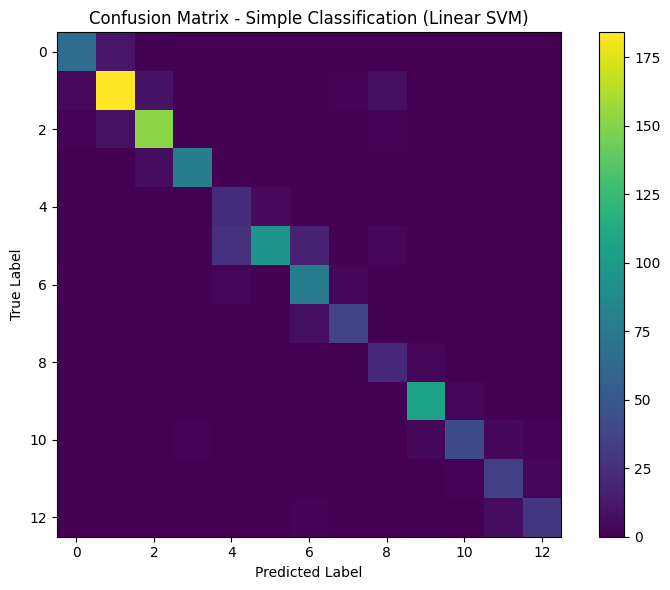

In [30]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_class_val, y_class_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Simple Classification (Linear SVM)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.tight_layout()
plt.show()

In [31]:
import joblib

joblib.dump(simple_clf, "simple_classification_linear_svm.joblib")
print("Saved: simple_classification_linear_svm.joblib")

Saved: simple_classification_linear_svm.joblib


In [32]:
#Advanced Regression — Deep Neural Network
y_scaler = StandardScaler()

y_reg_train_scaled = y_scaler.fit_transform(y_reg_train)
y_reg_val_scaled = y_scaler.transform(y_reg_val)

print("Original target shape:", y_reg_train.shape)
print("Scaled target shape:", y_reg_train_scaled.shape)

Original target shape: (19300, 2)
Scaled target shape: (19300, 2)


In [33]:
reg_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(2)
])

reg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

reg_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )
]

history_reg = reg_model.fit(
    X_train,
    y_reg_train_scaled,
    validation_data=(X_val, y_reg_val_scaled),
    epochs=80,
    batch_size=128,
    callbacks=reg_callbacks,
    verbose=1
)

Epoch 1/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.4004 - mae: 0.4468 - val_loss: 0.2811 - val_mae: 0.3102 - learning_rate: 0.0010
Epoch 2/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1317 - mae: 0.2711 - val_loss: 0.1291 - val_mae: 0.2026 - learning_rate: 0.0010
Epoch 3/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0854 - mae: 0.2193 - val_loss: 0.0704 - val_mae: 0.1573 - learning_rate: 0.0010
Epoch 4/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0626 - mae: 0.1876 - val_loss: 0.0675 - val_mae: 0.1445 - learning_rate: 0.0010
Epoch 5/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0503 - mae: 0.1675 - val_loss: 0.0578 - val_mae: 0.1358 - learning_rate: 0.0010
Epoch 6/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0414 - mae: 0.1520 - val_loss: 0.0576 - val_mae: 0.1311 - learning_rate: 0.0010
Epoch 7/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0363 - mae: 0.1426 - val_loss: 0.0422 - val_mae: 0.1169 - learning_rate: 0.0010
Epoc

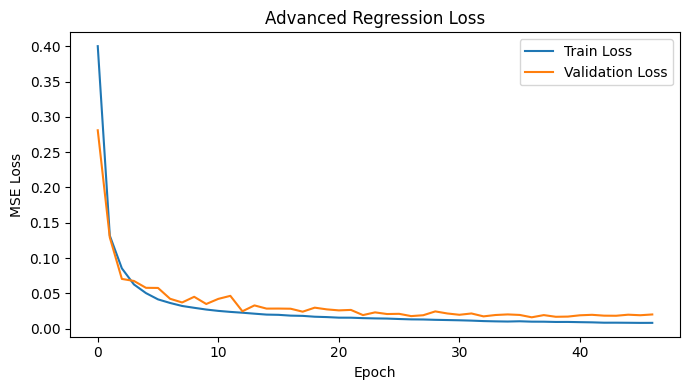

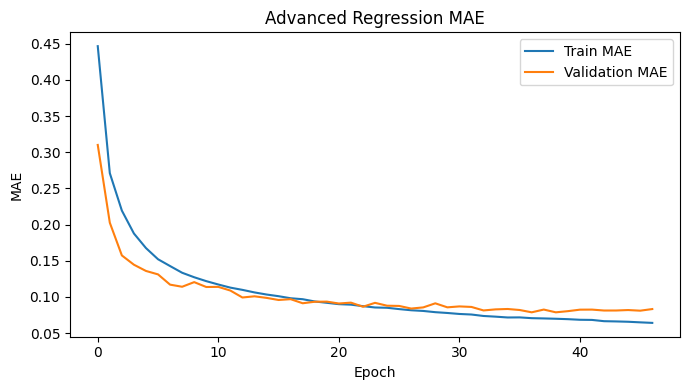

In [34]:
plt.figure(figsize=(7,4))
plt.plot(history_reg.history["loss"], label="Train Loss")
plt.plot(history_reg.history["val_loss"], label="Validation Loss")
plt.title("Advanced Regression Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history_reg.history["mae"], label="Train MAE")
plt.plot(history_reg.history["val_mae"], label="Validation MAE")
plt.title("Advanced Regression MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
y_reg_pred_scaled = reg_model.predict(X_val, verbose=0)
y_reg_pred = y_scaler.inverse_transform(y_reg_pred_scaled)

mae = mean_absolute_error(y_reg_val, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_val, y_reg_pred))

coord_error = np.linalg.norm(y_reg_val - y_reg_pred, axis=1)

print("Advanced Regression (Deep Neural Network)")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Mean Euclidean Coordinate Error: {coord_error.mean():.4f}")

print("\nPer-target MAE:")
print("Longitude MAE:", mean_absolute_error(y_reg_val[:, 0], y_reg_pred[:, 0]))
print("Latitude MAE: ", mean_absolute_error(y_reg_val[:, 1], y_reg_pred[:, 1]))

Advanced Regression (Deep Neural Network)
MAE:  7.0791
RMSE: 11.3116
Mean Euclidean Coordinate Error: 11.1018

Per-target MAE:
Longitude MAE: 7.750969409942627
Latitude MAE:  6.407290935516357


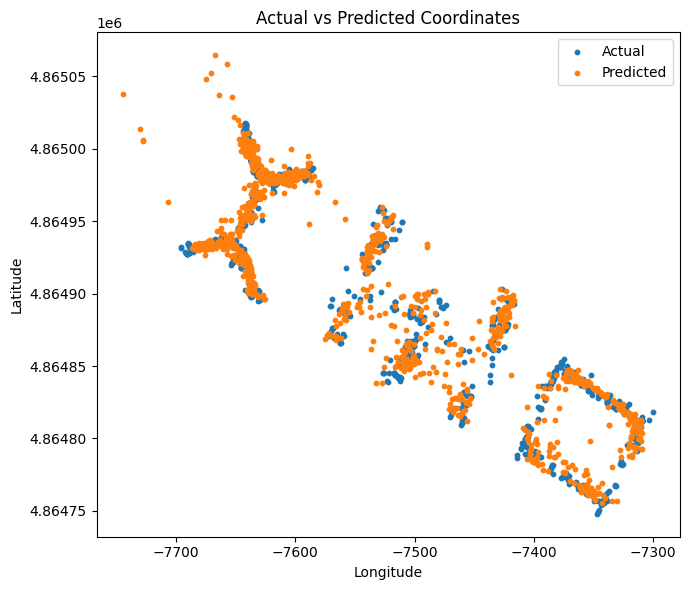

In [36]:
plt.figure(figsize=(7,6))
plt.scatter(y_reg_val[:, 0], y_reg_val[:, 1], s=10, label="Actual")
plt.scatter(y_reg_pred[:, 0], y_reg_pred[:, 1], s=10, label="Predicted")
plt.title("Actual vs Predicted Coordinates")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Simple Regressor model: Ridge Regression

# Initialize model
ridge_model = Ridge(alpha=1.0)

# Train
ridge_model.fit(X_train, y_reg_train)

# Predict
y_pred_ridge = ridge_model.predict(X_val)

# Evaluate
ridge_mae = mean_absolute_error(y_reg_val, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_reg_val, y_pred_ridge))

print("Ridge Regression Results:")
print(f"MAE:  {ridge_mae:.4f}")
print(f"RMSE: {ridge_rmse:.4f}")

Ridge Regression Results:
MAE:  32.6779
RMSE: 47.3689


In [38]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.neural_network import MLPRegressor

mlp_reg = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=200, random_state=42)

mlp_reg.fit(X_train, y_reg_train)

y_pred_mlp = mlp_reg.predict(X_val)

mlp_mae = mean_absolute_error(y_reg_val, y_pred_mlp)
mlp_rmse = np.sqrt(mean_squared_error(y_reg_val, y_pred_mlp))

print("MLP Regressor Results:")
print(f"MAE:  {mlp_mae:.4f}")
print(f"RMSE: {mlp_rmse:.4f}")

MLP Regressor Results:
MAE:  152857.5625
RMSE: 362556.5260


In [39]:
# Advanced Regressor model: Random Forest
from sklearn.ensemble import RandomForestRegressor
# Initialize model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train
rf_model.fit(X_train, y_reg_train)

# Predict
y_pred_rf = rf_model.predict(X_val)

# Evaluate
rf_mae = mean_absolute_error(y_reg_val, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_reg_val, y_pred_rf))

print("Random Forest Regressor Results:")
print(f"MAE:  {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")

Random Forest Regressor Results:
MAE:  8.1135
RMSE: 13.2315


In [40]:
# JAWAHER - Classification: Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# detect classification labels already created in notebook
if 'y_train_class' in globals():
    y_cls_train = y_train_class
    y_cls_val = y_val_class
elif 'y_class_train' in globals():
    y_cls_train = y_class_train
    y_cls_val = y_class_val
else:
    raise NameError("Classification target variables not found.")

# detect feature matrices already created in notebook
if 'X_train' in globals():
    Xtr = X_train
    Xv = X_val
elif 'X_train_scaled' in globals():
    Xtr = X_train_scaled
    Xv = X_val_scaled
elif 'X_train_scaled_df' in globals():
    Xtr = X_train_scaled_df
    Xv = X_val_scaled_df
else:
    raise NameError("Feature matrices not found.")

log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(Xtr, y_cls_train)

y_pred_log = log_reg.predict(Xv)

log_acc = accuracy_score(y_cls_val, y_pred_log)
log_f1 = f1_score(y_cls_val, y_pred_log, average='macro')

print("Logistic Regression Classification Results:")
print(f"Accuracy: {log_acc:.4f}")
print(f"F1-score: {log_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_cls_val, y_pred_log))

Logistic Regression Classification Results:
Accuracy: 0.8848
F1-score: 0.8746

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.89        78
           1       0.94      0.90      0.92       208
           2       0.86      0.96      0.91       165
           3       0.99      0.88      0.93        85
           4       0.49      0.83      0.62        30
           5       0.95      0.67      0.79       143
           6       0.75      0.92      0.83        87
           7       0.88      0.94      0.91        47
           8       0.96      0.92      0.94        24
           9       0.94      0.97      0.96       111
          10       0.94      0.87      0.90        54
          11       0.88      0.90      0.89        40
          12       0.88      0.90      0.89        39

    accuracy                           0.88      1111
   macro avg       0.87      0.89      0.87      1111
weighted avg       0.90      0.8

<Figure size 800x600 with 0 Axes>

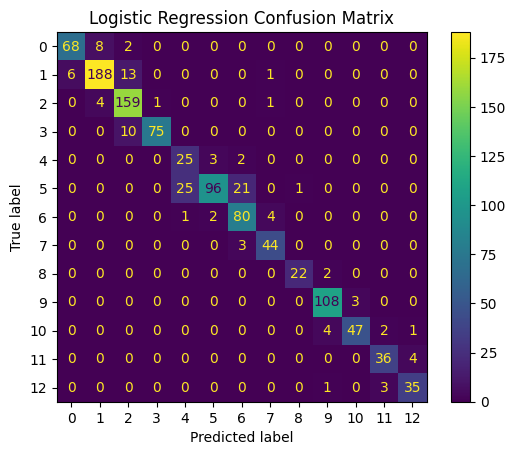

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_cls_val, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(8,6))
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [43]:
print("Summary of Jawaher Models")
print("------------------------")
print(f"Classification Accuracy: {log_acc:.4f}")
print(f"Classification F1: {log_f1:.4f}")
print(f"Regression MAE: {gbr_mae:.4f}")
print(f"Regression RMSE: {gbr_rmse:.4f}")

Summary of Jawaher Models
------------------------
Classification Accuracy: 0.8848
Classification F1: 0.8746
Regression MAE: 20.1359
Regression RMSE: 29.6016


In [41]:
# JAWAHER - Regression: Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# detect regression targets already created in notebook
if 'y_reg_train' not in globals() or 'y_reg_val' not in globals():
    raise NameError("Regression target variables y_reg_train / y_reg_val not found.")

# reuse feature matrices from above
gbr = MultiOutputRegressor(
    GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
)

gbr.fit(Xtr, y_reg_train)

y_pred_gbr = gbr.predict(Xv)

gbr_mae = mean_absolute_error(y_reg_val, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_reg_val, y_pred_gbr))

print("Gradient Boosting Regressor Results:")
print(f"MAE: {gbr_mae:.4f}")
print(f"RMSE: {gbr_rmse:.4f}")

Gradient Boosting Regressor Results:
MAE: 20.1359
RMSE: 29.6016


**FINAL INTERPRETATION**: Among all regression models, the deep neural network regressor achieved the best localization accuracy, followed by Random Forest, Gradient Boosting, and k-NN. For classification, the CNN model outperformed traditional machine learning approaches, while Logistic Regression provided a strong baseline performance. These results highlight the importance of capturing non-linear patterns in WiFi signal data for indoor positioning systems.